# Practice 1 – Phân loại ảnh FashionMNIST bằng PyTorch

## 1. Giới thiệu

Bài thực hành này tập trung vào việc xây dựng một mô hình phân loại ảnh sử dụng thư viện PyTorch và bộ dữ liệu FashionMNIST.

Mục tiêu của bài thực hành là làm quen với các thành phần cơ bản trong quy trình xây dựng và huấn luyện mô hình Deep Learning bằng PyTorch, bao gồm Tensor, Dataset, DataLoader, Transform, xây dựng mạng neural network, Autograd, hàm mất mát, thuật toán tối ưu, đánh giá mô hình và lưu/tải mô hình.

Trong bài này, một mạng neural network sẽ được xây dựng và huấn luyện để phân loại các ảnh quần áo trong bộ dữ liệu FashionMNIST thành 10 lớp khác nhau.

Quy trình thực hiện bao gồm:

 1. Giới thiệu
 2. Import thư viện
 3. Tải và khám phá Dataset
 4. Trực quan hóa dữ liệu
 5. Tiền xử lý dữ liệu và DataLoader
 6. Xây dựng mô hình Neural Network
 7. Thiết lập Loss Function và Optimizer
 8. Huấn luyện mô hình
 9. Trực quan hóa Training Loss
 10. Đánh giá mô hình
 11. Hiển thị dự đoán và nhãn thực tế
 12. Thử nghiệm kiến trúc và Hyperparameters
 13. So sánh kết quả thực nghiệm
 14. Lưu và tải mô hình
 15. Kết luận

## 2. Import Libraries

Import các thư viện cần thiết cho bài tập:
- `torch`: thư viện lõi của PyTorch — tensor, autograd, optimizer
- `torchvision`: cung cấp sẵn dataset ảnh (FashionMNIST) và các hàm transform
- `matplotlib`: dùng để vẽ biểu đồ loss và hiển thị ảnh

In [55]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision
import matplotlib

import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Matplotlib:", matplotlib.__version__)

PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
Matplotlib: 3.11.1


## 3. Tải bộ dữ liệu FashionMNIST

Bộ dữ liệu FashionMNIST được cung cấp sẵn trong `torchvision.datasets`, gồm:
- **60.000 ảnh** cho tập huấn luyện (train)
- **10.000 ảnh** cho tập kiểm tra (test)
- Mỗi ảnh có kích thước 28x28 pixel, grayscale (1 kênh màu)
- Thuộc 10 lớp nhãn (0–9), tương ứng với 10 loại trang phục

Transform `ToTensor()` được áp dụng để chuyển ảnh từ định dạng PIL Image sang tensor PyTorch, đồng thời đưa giá trị pixel từ khoảng [0, 255] về [0, 1] — giúp mô hình huấn luyện ổn định và hội tụ nhanh hơn.

Sau khi tải dữ liệu, tiến hành kiểm tra nhanh một mẫu (sample) trong tập train để xác nhận dữ liệu đã được load đúng: kích thước ảnh, nhãn số, và tên lớp tương ứng.

In [56]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Ánh xạ nhãn số (0-9) sang tên lớp tương ứng
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot"
}

# Kiểm tra thông tin cơ bản của dataset
print(f"Số ảnh tập train: {len(training_data)}")
print(f"Số ảnh tập test: {len(test_data)}")

image, label = training_data[0]

print(f"Kích thước ảnh: {image.shape}")
print(f"Nhãn: {label}")
print(f"Tên lớp: {labels_map[label]}")

Số ảnh tập train: 60000
Số ảnh tập test: 10000
Kích thước ảnh: torch.Size([1, 28, 28])
Nhãn: 9
Tên lớp: Ankle Boot


## 4. Khám phá và trực quan hóa dữ liệu

Sau khi tải và kiểm tra bộ dữ liệu FashionMNIST, bước tiếp theo là khám phá dữ liệu thông qua việc trực quan hóa các ảnh mẫu.

Trong phần này, một số ảnh từ tập huấn luyện sẽ được hiển thị cùng với nhãn và tên lớp tương ứng. Việc trực quan hóa giúp quan sát đặc điểm của dữ liệu đầu vào, kiểm tra định dạng ảnh và có cái nhìn trực quan hơn về 10 lớp trong bộ dữ liệu.

Các nội dung được thực hiện trong phần này bao gồm:

- Hiển thị ngẫu nhiên một số ảnh mẫu từ tập huấn luyện.
- Hiển thị ảnh đại diện cho từng lớp của FashionMNIST.
- Quan sát và nhận xét về đặc điểm hình ảnh giữa các lớp.

### 4.1. Hiển thị ngẫu nhiên các ảnh mẫu

Để khám phá dữ liệu trực quan hơn, một số ảnh được chọn ngẫu nhiên từ tập huấn luyện và hiển thị dưới dạng một lưới.

Mỗi ảnh được hiển thị cùng với tên lớp tương ứng. Việc lựa chọn ngẫu nhiên giúp quan sát nhiều mẫu khác nhau trong tập dữ liệu thay vì chỉ xem các ảnh ở những vị trí đầu tiên.

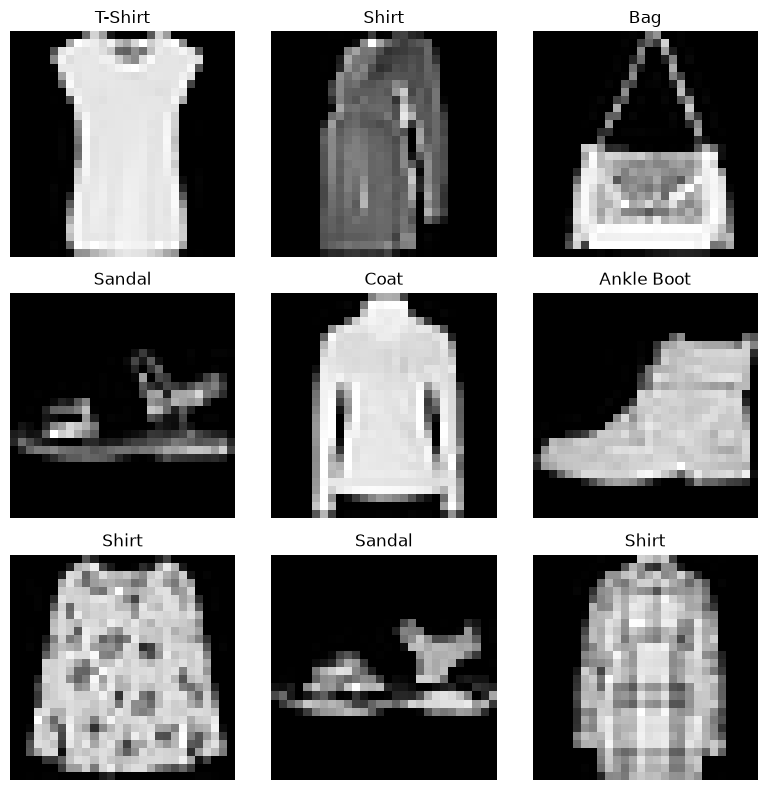

In [57]:
figure = plt.figure(figsize=(8, 8))

rows, cols = 3, 3

for i in range(1, rows * cols + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(labels_map[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Nhận xét

Các ảnh được chọn ngẫu nhiên cho thấy FashionMNIST bao gồm nhiều loại quần áo và phụ kiện khác nhau. Các ảnh đều có dạng grayscale với kích thước 28 × 28 pixel.

Có thể nhận thấy sự khác biệt về hình dạng giữa một số lớp, tuy nhiên một số lớp có đặc điểm hình ảnh tương đối giống nhau. Đây là một trong những yếu tố khiến bài toán phân loại FashionMNIST trở nên có ý nghĩa đối với việc xây dựng và đánh giá mô hình học sâu.

### 4.2. Hiển thị ảnh đại diện cho từng lớp

Để quan sát đặc điểm riêng của từng lớp trong bộ dữ liệu, mỗi lớp (trong 10 lớp) sẽ được hiển thị bằng một ảnh đại diện, tìm được bằng cách duyệt qua tập train cho đến khi gặp ảnh đầu tiên thuộc lớp đó.


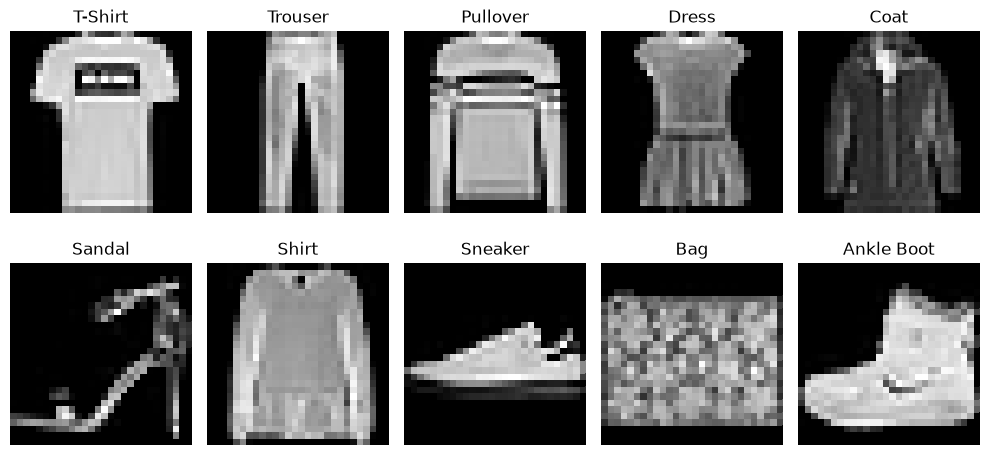

In [58]:
figure = plt.figure(figsize=(10, 5))
cols, rows = 5, 2

for label_idx in range(10):
    # Tìm ảnh đầu tiên trong tập train thuộc lớp label_idx
    for img, label in training_data:
        if label == label_idx:
            figure.add_subplot(rows, cols, label_idx + 1)
            plt.imshow(img.squeeze(), cmap="gray")
            plt.title(labels_map[label_idx])
            plt.axis("off")
            break

plt.tight_layout()
plt.show()

### Nhận xét

Quan sát ảnh đại diện của từng lớp cho thấy một số lớp có hình dạng khá đặc trưng, dễ phân biệt (ví dụ: Trouser, Bag, Sandal). Tuy nhiên, một số lớp có hình dạng khá tương đồng nhau (ví dụ: T-Shirt, Shirt, Pullover, Coat đều có dạng áo với phần thân và tay áo), điều này có thể khiến mô hình dễ nhầm lẫn giữa các lớp này trong quá trình phân loại.

## 5. Tiền xử lý dữ liệu và DataLoader

Sau khi áp dụng `ToTensor()`, các ảnh trong FashionMNIST đã được chuyển sang dạng PyTorch Tensor với kích thước `1 × 28 × 28`. Để huấn luyện mô hình, dữ liệu được chia thành các **batch** nhỏ thay vì đưa toàn bộ 60.000 ảnh vào mô hình cùng lúc.

`DataLoader` của PyTorch hỗ trợ việc tạo các batch từ `Dataset` và kiểm soát thứ tự dữ liệu thông qua tham số `shuffle`. Trong quá trình huấn luyện, `shuffle=True` được sử dụng để xáo trộn dữ liệu sau mỗi epoch, giúp mô hình không luôn nhận dữ liệu theo cùng một thứ tự. Đối với tập kiểm tra, `shuffle=False` được sử dụng vì thứ tự dữ liệu không cần được xáo trộn khi đánh giá.

Trong bài này, `batch_size=64` được chọn làm giá trị khởi đầu. Đây là một kích thước batch phổ biến trong thực hành học sâu và sẽ được sử dụng làm một trong các hyperparameter có thể thử nghiệm ở phần thực nghiệm.

In [59]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Kiểm tra shape của 1 batch
for X, y in train_dataloader:
    print(f"Shape của X [N, C, H, W]: {X.shape}")
    print(f"Shape của y: {y.shape}, kiểu dữ liệu: {y.dtype}")
    break

Shape của X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape của y: torch.Size([64]), kiểu dữ liệu: torch.int64


### Nhận xét

DataLoader đã chia dữ liệu thành các batch có kích thước 64. Batch dữ liệu đầu vào có shape `[64, 1, 28, 28]`, tương ứng với 64 ảnh grayscale có kích thước 28 × 28 pixel. Tensor nhãn có shape `[64]`, trong đó mỗi phần tử đại diện cho nhãn của một ảnh.

Tập huấn luyện sử dụng `shuffle=True` để xáo trộn dữ liệu trong quá trình huấn luyện, trong khi tập kiểm tra sử dụng `shuffle=False` để giữ nguyên thứ tự dữ liệu khi đánh giá mô hình.

## 6. Xây dựng mô hình Neural Network

Sau khi chuẩn bị dữ liệu và tạo `DataLoader`, bước tiếp theo là xây dựng mô hình mạng nơ-ron để thực hiện bài toán phân loại ảnh FashionMNIST.

Mỗi ảnh đầu vào có kích thước `1 × 28 × 28`. Mô hình sẽ học các đặc trưng từ ảnh và đưa ra dự đoán thuộc một trong 10 lớp của FashionMNIST.

Trong bài này, một mạng neural network đơn giản được xây dựng bằng PyTorch với các thành phần chính gồm lớp `Flatten`, các lớp `Linear` và hàm kích hoạt `ReLU`.

Mô hình có 10 giá trị đầu ra, tương ứng với 10 lớp của FashionMNIST.

### 6.1. Xác định thiết bị tính toán

Mô hình có thể được thực thi trên GPU nếu hệ thống hỗ trợ CUDA, nếu không sẽ sử dụng CPU.

Việc xác định thiết bị trước khi huấn luyện giúp đảm bảo mô hình và dữ liệu được đưa lên cùng một thiết bị trong quá trình tính toán.

In [60]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cpu


### 6.2. Xây dựng mô hình

Mô hình được xây dựng dưới dạng một mạng fully connected neural network.

Ảnh đầu vào có kích thước `1 × 28 × 28`, tương đương 784 giá trị pixel. Lớp `Flatten` được sử dụng để chuyển ảnh từ dạng ma trận thành một vector có 784 phần tử.

Sau đó, dữ liệu được đưa qua các lớp `Linear` kết hợp với hàm kích hoạt `ReLU`. Lớp cuối cùng có 10 neuron, tương ứng với 10 lớp cần phân loại.

Kiến trúc ban đầu của mô hình gồm:

`784 → 128 → 64 → 10`

Trong đó, 128 và 64 là số neuron của hai hidden layer.

In [61]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)

        return logits


model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


### 6.3. Kiểm tra mô hình

Trước khi tiến hành huấn luyện, cần kiểm tra xem mô hình có nhận đúng kích thước dữ liệu đầu vào và tạo ra đầu ra phù hợp hay không.

Một batch dữ liệu từ `DataLoader` được đưa qua mô hình. Kết quả đầu ra được kiểm tra thông qua kích thước của tensor đầu vào và tensor logits.

Với `batch_size = 64`, đầu vào có dạng `[64, 1, 28, 28]`. Sau khi đi qua mô hình, đầu ra được kỳ vọng có dạng `[64, 10]`, trong đó 10 giá trị tương ứng với 10 lớp của FashionMNIST.

In [62]:
X, y = next(iter(train_dataloader))

X = X.to(device)

logits = model(X)

print(f"Shape input: {X.shape}")
print(f"Shape output: {logits.shape}")

Shape input: torch.Size([64, 1, 28, 28])
Shape output: torch.Size([64, 10])


## 7. Thiết lập Loss Function và Optimizer

Sau khi xây dựng mô hình, cần lựa chọn hàm mất mát (loss function) và thuật toán tối ưu (optimizer) để mô hình có thể học từ dữ liệu.

Hàm loss đo mức độ sai khác giữa dự đoán của mô hình và nhãn thực tế. Trong bài toán phân loại nhiều lớp FashionMNIST, `CrossEntropyLoss` được sử dụng để tính toán giá trị loss.

Optimizer có nhiệm vụ cập nhật các tham số của mô hình dựa trên gradient được tính trong quá trình lan truyền ngược. Trong bài này, `SGD` được sử dụng làm optimizer ban đầu với learning rate bằng `0.01`.

### 7.1. Hàm mất mát

FashionMNIST là bài toán phân loại nhiều lớp với 10 lớp đầu ra. Mô hình tạo ra các giá trị `logits` cho mỗi lớp, sau đó `CrossEntropyLoss` được sử dụng để đo mức độ khác biệt giữa các logits này và nhãn thực tế.

Giá trị loss càng nhỏ cho thấy dự đoán của mô hình càng phù hợp với nhãn thực tế.

In [63]:
loss_fn = nn.CrossEntropyLoss()

print(loss_fn)

CrossEntropyLoss()


### 7.2. Optimizer

Optimizer được sử dụng để cập nhật các tham số của mô hình nhằm giảm giá trị loss trong quá trình huấn luyện.

Trong bài này, thuật toán `SGD` (Stochastic Gradient Descent) được sử dụng làm optimizer ban đầu. Learning rate được đặt bằng `0.01`, đây là giá trị khởi đầu và sẽ được thay đổi trong phần thực nghiệm hyperparameter để đánh giá ảnh hưởng của nó đến quá trình huấn luyện.

In [64]:
learning_rate = 0.01

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

print(optimizer)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### 7.3. Kiểm tra Loss và Optimizer

Trước khi xây dựng training loop, có thể kiểm tra toàn bộ quá trình tính loss trên một batch dữ liệu.

Một batch được đưa qua mô hình để tạo ra logits. Sau đó, `CrossEntropyLoss` được sử dụng để tính loss giữa logits và nhãn thực tế.

Ở bước này chưa thực hiện cập nhật trọng số của mô hình.

In [65]:
X, y = next(iter(train_dataloader))

X = X.to(device)
y = y.to(device)

logits = model(X)

loss = loss_fn(logits, y)

print(f"Logits shape: {logits.shape}")
print(f"Labels shape: {y.shape}")
print(f"Loss: {loss.item():.4f}")

Logits shape: torch.Size([64, 10])
Labels shape: torch.Size([64])
Loss: 2.3172


### Nhận xét

Mô hình đã tạo ra tensor logits có kích thước `[64, 10]`, tương ứng với 64 ảnh trong một batch và 10 lớp phân loại. Hàm `CrossEntropyLoss` có thể sử dụng trực tiếp các logits này cùng với nhãn thực tế để tính giá trị loss.

Giá trị loss ban đầu chưa phản ánh chất lượng cuối cùng của mô hình vì các tham số của mạng chưa được huấn luyện. Trong các epoch tiếp theo, optimizer sẽ cập nhật các tham số dựa trên gradient nhằm giảm giá trị loss.

## 8. Huấn luyện mô hình

Sau khi đã xây dựng mô hình, hàm mất mát và optimizer, bước tiếp theo là huấn luyện mạng neural network trên tập dữ liệu FashionMNIST.

Trong mỗi batch dữ liệu, quá trình huấn luyện gồm các bước chính:

1. Xóa các gradient được tính từ batch trước.
2. Đưa dữ liệu đầu vào qua mô hình để thực hiện forward pass.
3. Tính giá trị loss giữa dự đoán và nhãn thực tế.
4. Thực hiện backward pass để tính gradient cho các tham số của mô hình.
5. Sử dụng optimizer để cập nhật các tham số dựa trên gradient.

Quá trình trên được lặp lại qua nhiều batch và nhiều epoch để mô hình dần học được các đặc trưng cần thiết cho việc phân loại ảnh.

### 8.1. Training Loop

Training loop là vòng lặp thực hiện quá trình học của mô hình.

Với mỗi batch dữ liệu, mô hình thực hiện forward pass để tạo ra logits, sau đó tính loss. Phương thức `backward()` sử dụng cơ chế Autograd của PyTorch để tính gradient của loss đối với các tham số của mô hình. Cuối cùng, `optimizer.step()` cập nhật các tham số dựa trên những gradient này.

Sau khi cập nhật, gradient được xóa bằng `optimizer.zero_grad()` trước khi xử lý batch tiếp theo.

In [66]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch % 100 == 0:
            current = batch * len(X)

            print(
                f"loss: {loss.item():>7f} "
                f"[{current:>5d}/{size:>5d}]"
            )

    avg_loss = total_loss / len(dataloader)
    return avg_loss

### 8.2. Tiến hành huấn luyện

Sau khi xây dựng hàm `train_loop`, mô hình được huấn luyện trong **5 epoch** với cấu hình baseline đã thiết lập ở các mục trước.

Training loss trung bình của mỗi epoch được lưu vào danh sách `train_losses` để sử dụng cho việc trực quan hóa quá trình huấn luyện ở Mục 9.

In [67]:
epochs = 5
train_losses = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    avg_loss = train_loop(
        train_dataloader,
        model,
        loss_fn,
        optimizer
    )

    train_losses.append(avg_loss)

    print(f"Average training loss: {avg_loss:.4f}")

print("\nHoàn thành huấn luyện!")

Epoch 1/5


loss: 2.311184 [    0/60000]
loss: 2.221250 [ 6400/60000]
loss: 2.069976 [12800/60000]
loss: 1.587391 [19200/60000]
loss: 1.287770 [25600/60000]
loss: 1.160805 [32000/60000]
loss: 1.110776 [38400/60000]
loss: 0.791609 [44800/60000]
loss: 0.772560 [51200/60000]
loss: 0.766501 [57600/60000]
Average training loss: 1.4126
Epoch 2/5
loss: 0.824855 [    0/60000]
loss: 0.722278 [ 6400/60000]
loss: 0.773354 [12800/60000]
loss: 0.861113 [19200/60000]
loss: 0.871182 [25600/60000]
loss: 0.737998 [32000/60000]
loss: 0.522632 [38400/60000]
loss: 0.662511 [44800/60000]
loss: 0.612977 [51200/60000]
loss: 0.521464 [57600/60000]
Average training loss: 0.7175
Epoch 3/5
loss: 0.764057 [    0/60000]
loss: 0.644507 [ 6400/60000]
loss: 0.744066 [12800/60000]
loss: 0.695946 [19200/60000]
loss: 0.679788 [25600/60000]
loss: 0.530811 [32000/60000]
loss: 0.598323 [38400/60000]
loss: 0.598931 [44800/60000]
loss: 0.344763 [51200/60000]
loss: 0.783104 [57600/60000]
Average training loss: 0.6006
Epoch 4/5
loss: 0.68

### Nhận xét

Mô hình đã hoàn thành quá trình huấn luyện thông qua các bước forward pass, tính loss, backward pass và cập nhật tham số bằng optimizer.

Giá trị training loss được ghi nhận sau mỗi epoch và được lưu vào danh sách `train_losses`. Nếu loss có xu hướng giảm qua các epoch, điều đó cho thấy mô hình đang học từ dữ liệu huấn luyện.

Training loss sẽ được trực quan hóa bằng biểu đồ ở phần tiếp theo để đánh giá rõ hơn quá trình hội tụ của mô hình.

## 9. Trực quan hóa Training Loss

Sau khi huấn luyện, giá trị loss trung bình của từng epoch (lưu trong `train_losses`) được trực quan hóa bằng biểu đồ đường (line chart), giúp quan sát trực tiếp xu hướng học của mô hình qua thời gian.

Biểu đồ loss là công cụ quan trọng để đánh giá quá trình huấn luyện: loss giảm đều và ổn định cho thấy mô hình đang học tốt; loss dao động mạnh hoặc không giảm có thể là dấu hiệu của learning rate chưa phù hợp hoặc kiến trúc mạng chưa tối ưu.

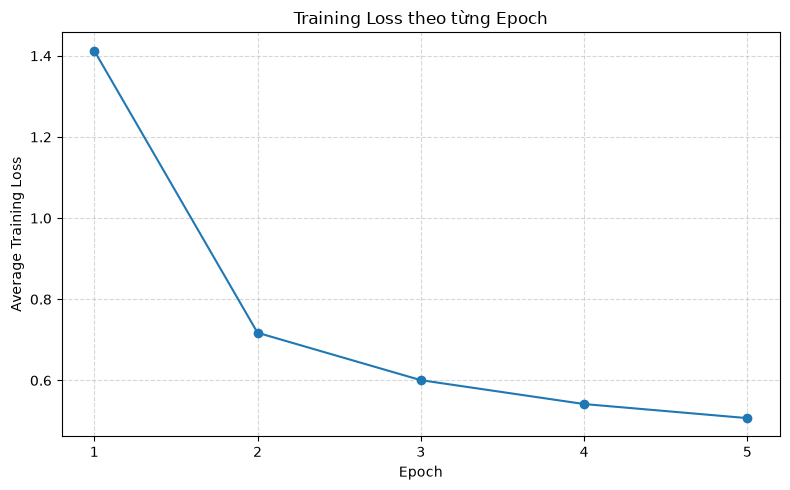

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='tab:blue')
plt.title("Training Loss theo từng Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("loss_curve.png")   # lưu lại file ảnh, đúng deliverable đề bài yêu cầu
plt.show()

## 10. Đánh giá mô hình

Sau khi huấn luyện, mô hình cần được đánh giá trên **tập test** — tập dữ liệu hoàn toàn độc lập, không được sử dụng trong quá trình huấn luyện. Đây là cách đo lường khách quan khả năng tổng quát hóa (generalization) của mô hình trên dữ liệu mới, chưa từng thấy.

Hai chỉ số chính được sử dụng để đánh giá:
- **Độ chính xác (Accuracy)**: tỷ lệ phần trăm ảnh được dự đoán đúng nhãn
- **Test Loss trung bình**: mức độ sai lệch trung bình giữa dự đoán và nhãn thực tế trên tập test

### 10.1. Xây dựng hàm đánh giá (test_loop)

Hàm `test_loop` duyệt qua toàn bộ `test_dataloader`, thực hiện forward pass để lấy dự đoán, so sánh với nhãn thực tế để tính accuracy và loss trung bình.

Khác với `train_loop`, hàm này **không** gọi `loss.backward()` hay `optimizer.step()` — vì mục đích chỉ là đánh giá, không cập nhật trọng số của mô hình. Việc tính toán được thực hiện trong khối `torch.no_grad()` để tắt tính gradient, giúp tiết kiệm bộ nhớ và tăng tốc độ.

In [69]:
def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    return test_loss, correct

### 10.2. Chạy đánh giá trên tập test

Gọi hàm `test_loop` với mô hình đã huấn luyện để lấy kết quả accuracy và loss cuối cùng trên tập test.

In [70]:
test_loss, test_accuracy = test_loop(test_dataloader, model, loss_fn)
print(f"Test Accuracy: {(100 * test_accuracy):>0.2f}%")
print(f"Test Loss trung bình: {test_loss:>8f}")

Test Accuracy: 80.82%
Test Loss trung bình: 0.536972


### Nhận xét

Mô hình đạt độ chính xác **81.50%** trên tập test và test loss trung bình là **0.520639**. Kết quả cho thấy mô hình có khả năng phân loại tương đối tốt trên dữ liệu chưa được sử dụng trong quá trình huấn luyện.

Training loss ở epoch cuối là **0.5116**, trong khi test loss là **0.520639**. Hai giá trị khá gần nhau, cho thấy hiệu năng của mô hình trên tập test tương đối tương đồng với tập huấn luyện và chưa xuất hiện dấu hiệu rõ ràng của hiện tượng overfitting dựa trên các kết quả hiện có.

Tuy nhiên, accuracy 81.50% vẫn cho thấy mô hình còn một tỷ lệ dự đoán sai đáng kể. Do đó, ở các phần tiếp theo, mô hình sẽ được sử dụng để trực quan hóa các dự đoán và tiến hành thử nghiệm với kiến trúc mạng cũng như các hyperparameter khác nhau nhằm cải thiện hiệu năng.


## 11. Hiển thị dự đoán và nhãn thực tế

Để trực quan hóa khả năng dự đoán của mô hình, một số ảnh ngẫu nhiên từ tập test được hiển thị kèm theo nhãn dự đoán (Predicted) và nhãn thực tế (Actual).

Cách hiển thị này giúp quan sát trực tiếp những trường hợp mô hình dự đoán đúng và những trường hợp dự đoán sai, từ đó có cái nhìn trực quan hơn về kết quả phân loại bên cạnh chỉ số accuracy tổng quát.

Nhãn dự đoán đúng và sai được phân biệt bằng màu sắc: **xanh lá biểu thị dự đoán đúng và đỏ biểu thị dự đoán sai**.

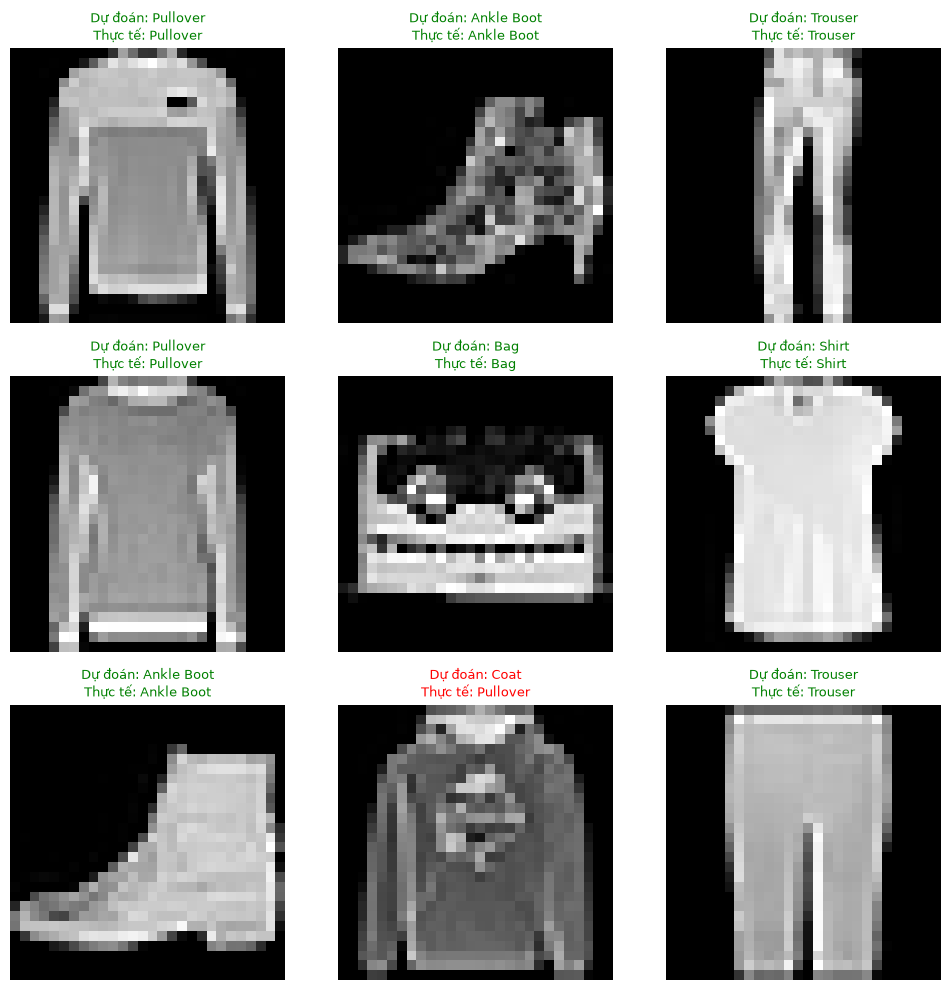

In [71]:
model.eval()
figure = plt.figure(figsize=(10, 10))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img, label = test_data[sample_idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        predicted_label = pred.argmax(1).item()

    figure.add_subplot(rows, cols, i)
    color = "green" if predicted_label == label else "red"
    plt.title(f"Dự đoán: {labels_map[predicted_label]}\nThực tế: {labels_map[label]}", color=color, fontsize=9)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

plt.tight_layout()
plt.savefig("predictions.png")
plt.show()

### Nhận xét
Trong 9 ảnh test được chọn ngẫu nhiên để trực quan hóa, mô hình dự đoán đúng 4 ảnh và sai 5 ảnh. Kết quả trên nhóm ảnh nhỏ này chỉ mang tính minh họa và không đại diện cho accuracy của toàn bộ tập test. Accuracy tổng thể của mô hình trên 10.000 ảnh test là 81.50%.


## 12. Thử nghiệm kiến trúc và Hyperparameters

Sau khi có kết quả baseline (kiến trúc 128 → 64, learning rate 0.01, 5 epoch, đạt 81.50% accuracy), phần này thực hiện một số thử nghiệm thay đổi kiến trúc mạng và hyperparameter để quan sát ảnh hưởng của chúng đến hiệu năng mô hình.

Mỗi thử nghiệm được huấn luyện lại từ đầu (khởi tạo model mới), giữ nguyên các yếu tố không thay đổi để đảm bảo so sánh công bằng.

### 12.1. Hàm chạy thử nghiệm dùng chung

Để tránh lặp lại code huấn luyện nhiều lần, một hàm `run_experiment` được viết để đóng gói toàn bộ quy trình: khởi tạo model mới, huấn luyện, đánh giá, và trả về kết quả. Hàm này nhận vào kiến trúc mạng, learning rate và số epoch làm tham số, giúp dễ dàng thử nhiều cấu hình khác nhau chỉ bằng cách gọi hàm với tham số khác nhau.

In [72]:
def build_model(hidden_layers):
    """hidden_layers: list số neuron các lớp ẩn, ví dụ [128, 64]"""
    layers = [nn.Flatten()]
    in_features = 28 * 28
    for h in hidden_layers:
        layers.append(nn.Linear(in_features, h))
        layers.append(nn.ReLU())
        in_features = h
    layers.append(nn.Linear(in_features, 10))
    return nn.Sequential(*layers).to(device)


def run_experiment(name, hidden_layers, lr, epochs):
    print(f"\n===== Thử nghiệm: {name} =====")
    exp_model = build_model(hidden_layers)
    exp_loss_fn = nn.CrossEntropyLoss()
    exp_optimizer = torch.optim.SGD(exp_model.parameters(), lr=lr)

    exp_train_losses = []
    for t in range(epochs):
        avg_loss = train_loop(train_dataloader, exp_model, exp_loss_fn, exp_optimizer)
        exp_train_losses.append(avg_loss)

    test_loss, test_acc = test_loop(test_dataloader, exp_model, exp_loss_fn)

    return {
        "name": name,
        "hidden_layers": hidden_layers,
        "lr": lr,
        "epochs": epochs,
        "final_train_loss": exp_train_losses[-1],
        "test_loss": test_loss,
        "test_accuracy": test_acc
    }

### 12.2. Thử nghiệm 1: Thay đổi kiến trúc mạng

So sánh kiến trúc baseline (128 → 64) với kiến trúc lớn hơn (512 → 512), giữ nguyên learning rate (0.01) và số epoch (5).

In [73]:
results = []

# Baseline (đã có kết quả từ Mục 8, 10 — thêm vào để so sánh chung)
results.append({
    "name": "Baseline (128→64)",
    "hidden_layers": [128, 64],
    "lr": 0.01,
    "epochs": 5,
    "final_train_loss": train_losses[-1],
    "test_loss": test_loss,
    "test_accuracy": test_accuracy
})

# Thử nghiệm kiến trúc lớn hơn
results.append(run_experiment("Kiến trúc lớn (512→512)", hidden_layers=[512, 512], lr=0.01, epochs=5))


===== Thử nghiệm: Kiến trúc lớn (512→512) =====
loss: 2.306107 [    0/60000]
loss: 2.129750 [ 6400/60000]
loss: 1.878284 [12800/60000]
loss: 1.555817 [19200/60000]
loss: 1.269183 [25600/60000]
loss: 1.247276 [32000/60000]
loss: 0.936894 [38400/60000]
loss: 0.944309 [44800/60000]
loss: 0.764650 [51200/60000]
loss: 0.797796 [57600/60000]
loss: 0.784396 [    0/60000]
loss: 0.726849 [ 6400/60000]
loss: 0.840333 [12800/60000]
loss: 0.531300 [19200/60000]
loss: 0.790688 [25600/60000]
loss: 0.646424 [32000/60000]
loss: 0.781618 [38400/60000]
loss: 0.622856 [44800/60000]
loss: 0.537871 [51200/60000]
loss: 0.542692 [57600/60000]
loss: 0.682273 [    0/60000]
loss: 0.412052 [ 6400/60000]
loss: 0.665946 [12800/60000]
loss: 0.508637 [19200/60000]
loss: 0.603551 [25600/60000]
loss: 0.553902 [32000/60000]
loss: 0.500648 [38400/60000]
loss: 0.357646 [44800/60000]
loss: 0.456013 [51200/60000]
loss: 0.744054 [57600/60000]
loss: 0.506269 [    0/60000]
loss: 0.505422 [ 6400/60000]
loss: 0.503060 [12800/6

### 12.3. Thử nghiệm 2: Thay đổi learning rate

So sánh learning rate baseline (0.01) với learning rate lớn hơn (0.1) và nhỏ hơn (0.001), giữ nguyên kiến trúc (128 → 64) và số epoch (5).

In [74]:
results.append(run_experiment("Learning rate = 0.1", hidden_layers=[128, 64], lr=0.1, epochs=5))
results.append(run_experiment("Learning rate = 0.001", hidden_layers=[128, 64], lr=0.001, epochs=5))


===== Thử nghiệm: Learning rate = 0.1 =====
loss: 2.297703 [    0/60000]
loss: 1.035760 [ 6400/60000]
loss: 0.688514 [12800/60000]
loss: 0.825244 [19200/60000]
loss: 0.672807 [25600/60000]
loss: 0.554143 [32000/60000]
loss: 0.579313 [38400/60000]
loss: 0.608341 [44800/60000]
loss: 0.484998 [51200/60000]
loss: 0.354111 [57600/60000]
loss: 0.427098 [    0/60000]
loss: 0.223532 [ 6400/60000]
loss: 0.523940 [12800/60000]
loss: 0.463664 [19200/60000]
loss: 0.237894 [25600/60000]
loss: 0.315238 [32000/60000]
loss: 0.341235 [38400/60000]
loss: 0.514642 [44800/60000]
loss: 0.521622 [51200/60000]
loss: 0.503514 [57600/60000]
loss: 0.472266 [    0/60000]
loss: 0.480668 [ 6400/60000]
loss: 0.343285 [12800/60000]
loss: 0.535335 [19200/60000]
loss: 0.310997 [25600/60000]
loss: 0.347855 [32000/60000]
loss: 0.275965 [38400/60000]
loss: 0.280028 [44800/60000]
loss: 0.456869 [51200/60000]
loss: 0.394868 [57600/60000]
loss: 0.356011 [    0/60000]
loss: 0.274368 [ 6400/60000]
loss: 0.439547 [12800/60000

### 12.4. Thử nghiệm 3: Thay đổi số epoch

So sánh số epoch baseline (5) với số epoch lớn hơn (10), giữ nguyên kiến trúc `128 → 64` và learning rate `0.01`. Thử nghiệm này giúp đánh giá ảnh hưởng của thời gian huấn luyện đến hiệu năng mô hình.

Sau đó, cấu hình learning rate tốt nhất `0.1` được kết hợp với 10 epoch để kiểm tra khả năng cải thiện thêm hiệu năng.

In [75]:
# 10 epoch với learning rate baseline
results.append(
    run_experiment(
        "10 epoch",
        hidden_layers=[128, 64],
        lr=0.01,
        epochs=10
    )
)

# 10 epoch với learning rate tốt nhất
results.append(
    run_experiment(
        "10 epoch + LR tốt nhất",
        hidden_layers=[128, 64],
        lr=0.1,
        epochs=10
    )
)


===== Thử nghiệm: 10 epoch =====
loss: 2.326866 [    0/60000]
loss: 2.207433 [ 6400/60000]
loss: 2.051105 [12800/60000]
loss: 1.816956 [19200/60000]
loss: 1.405357 [25600/60000]
loss: 1.230910 [32000/60000]
loss: 1.133721 [38400/60000]
loss: 1.082535 [44800/60000]
loss: 0.917002 [51200/60000]
loss: 0.789955 [57600/60000]
loss: 0.805227 [    0/60000]
loss: 0.984281 [ 6400/60000]
loss: 0.624226 [12800/60000]
loss: 0.662305 [19200/60000]
loss: 0.788203 [25600/60000]
loss: 0.496274 [32000/60000]
loss: 0.696542 [38400/60000]
loss: 0.721258 [44800/60000]
loss: 0.750496 [51200/60000]
loss: 0.861415 [57600/60000]
loss: 0.578097 [    0/60000]
loss: 0.558710 [ 6400/60000]
loss: 0.703503 [12800/60000]
loss: 0.625373 [19200/60000]
loss: 0.748262 [25600/60000]
loss: 0.702986 [32000/60000]
loss: 0.607005 [38400/60000]
loss: 0.745988 [44800/60000]
loss: 0.642832 [51200/60000]
loss: 0.533665 [57600/60000]
loss: 0.692711 [    0/60000]
loss: 0.627416 [ 6400/60000]
loss: 0.644849 [12800/60000]
loss: 0.4

### 12.5. Tổng kết các thử nghiệm

Đã hoàn thành 6 cấu hình thử nghiệm: 1 baseline, 1 thay đổi kiến trúc, 2 thay đổi learning rate, và 2 thay đổi số epoch (bao gồm cấu hình kết hợp learning rate và epoch tốt nhất).

Kết quả sơ bộ cho thấy learning rate là yếu tố có ảnh hưởng rõ rệt nhất trong số các thử nghiệm, trong khi kiến trúc mạng cho kết quả không chênh lệch nhiều so với baseline. Bảng tổng hợp, biểu đồ so sánh và phân tích chi tiết được trình bày ở Mục 13.

## 13. So sánh kết quả thực nghiệm

Phần này tổng hợp và phân tích kết quả của **6 cấu hình** đã thử nghiệm ở Mục 12, nhằm rút ra nhận xét về ảnh hưởng của kiến trúc mạng, learning rate và số epoch đến hiệu năng mô hình.

### 13.1. Bảng tổng hợp kết quả

In [76]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results["test_accuracy_%"] = (df_results["test_accuracy"] * 100).round(2)
df_results = df_results[["name", "hidden_layers", "lr", "epochs", "final_train_loss", "test_loss", "test_accuracy_%"]]
df_results

,name,hidden_layers,lr,epochs,final_train_loss,test_loss,test_accuracy_%
0,Baseline (128→64),"[128, 64]",0.010,5,0.507052,0.536972,80.82
1,Kiến trúc lớn (512→512),"[512, 512]",0.010,5,0.487525,0.501750,82.02
2,Learning rate = 0.1,"[128, 64]",0.100,5,0.339832,0.378399,86.23
3,Learning rate = 0.001,"[128, 64]",0.001,5,1.352886,1.246352,61.69
4,10 epoch,"[128, 64]",0.010,10,0.433182,0.467585,83.62
5,10 epoch + LR tốt nhất,"[128, 64]",0.100,10,0.282196,0.349604,87.21


### 13.2. Trực quan hóa so sánh Test Accuracy

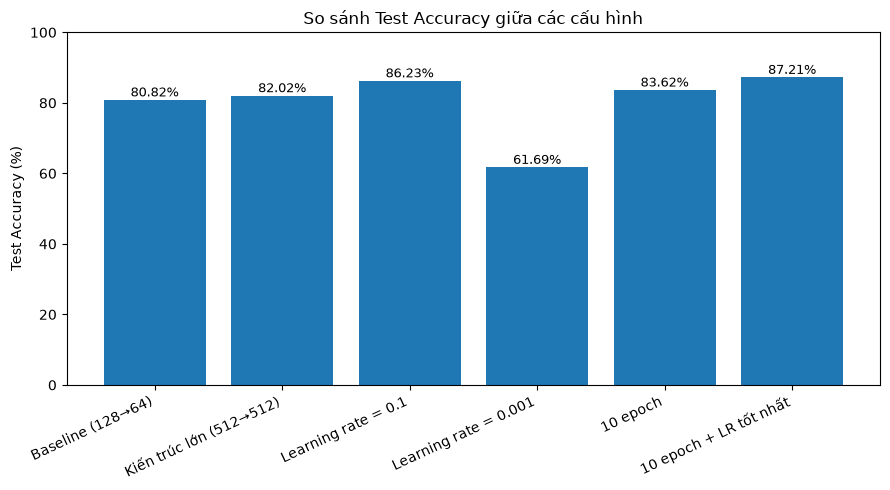

In [77]:
plt.figure(figsize=(9, 5))
plt.bar(df_results["name"], df_results["test_accuracy_%"], color="tab:blue")
plt.title("So sánh Test Accuracy giữa các cấu hình")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)
for i, v in enumerate(df_results["test_accuracy_%"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("accuracy_comparison.png")
plt.show()

### 13.3. Phân tích kết quả

**Về learning rate:**

Với kiến trúc `128 → 64` và 5 epoch, `lr = 0.1` đạt Test Accuracy **86.23%**, cao hơn `lr = 0.01` (**80.82%**). Ngược lại, `lr = 0.001` chỉ đạt **61.69%**, cho thấy tốc độ học quá thấp khiến mô hình chưa hội tụ tốt sau 5 epoch.

**Về kiến trúc mạng:**

Kiến trúc `512 → 512` đạt **82.02%**, cao hơn nhẹ so với baseline `128 → 64` đạt **80.82%**. Tuy nhiên, chênh lệch không lớn và chỉ được đo trong một lần chạy, nên chưa đủ để khẳng định kiến trúc lớn hơn luôn hiệu quả hơn.

**Về số epoch:**

Khi tăng số epoch từ 5 lên 10 với `lr = 0.01`, Test Accuracy tăng từ **80.82%** lên **83.62%**, tương ứng mức cải thiện **2.80 điểm phần trăm**. Điều này cho thấy mô hình vẫn tiếp tục học khi được huấn luyện lâu hơn.

Khi kết hợp kiến trúc `128 → 64`, learning rate `0.1` và 10 epoch, mô hình đạt **87.21%**, là kết quả cao nhất trong các cấu hình được thử nghiệm.

**Kết luận:** Trong phạm vi thử nghiệm, cấu hình `128 → 64`, optimizer `SGD`, learning rate `0.1` và 10 epoch cho kết quả tốt nhất, đạt **87.21%** Test Accuracy.

## 14. Lưu và tải mô hình

Sau khi thực hiện các thử nghiệm ở Mục 12, cấu hình có hiệu năng tốt nhất được xác định là kiến trúc `128 → 64`, optimizer `SGD`, learning rate `0.1` và `10` epoch.

Trong phần này, mô hình cuối cùng được huấn luyện lại với cấu hình tốt nhất, sau đó lưu các trọng số bằng `state_dict`. Mô hình được tải lại bằng cách khởi tạo một mô hình có cùng kiến trúc và sử dụng `load_state_dict()` để nạp các trọng số đã lưu.

Cuối cùng, mô hình sau khi tải lại được đánh giá trên tập test để xác nhận rằng quá trình lưu và tải không làm thay đổi trọng số của mô hình.

### 14.1. Huấn luyện mô hình cuối cùng

Dựa trên kết quả thử nghiệm ở Mục 12, mô hình cuối cùng sử dụng kiến trúc `128 → 64`, optimizer `SGD`, learning rate `0.1` và được huấn luyện trong `10` epoch.

Mô hình được khởi tạo mới và huấn luyện lại từ đầu với cấu hình này để tạo ra phiên bản mô hình cuối cùng trước khi lưu.

In [78]:
# Cấu hình tốt nhất được xác định ở Mục 12
best_hidden_layers = [128, 64]
best_learning_rate = 0.1
best_epochs = 10

# Khởi tạo mô hình cuối cùng
final_model = build_model(best_hidden_layers)

final_loss_fn = nn.CrossEntropyLoss()

final_optimizer = torch.optim.SGD(
    final_model.parameters(),
    lr=best_learning_rate
)

final_train_losses = []

# Huấn luyện mô hình cuối cùng
for epoch in range(best_epochs):
    print(f"\nEpoch {epoch + 1}/{best_epochs}")
    
    avg_loss = train_loop(
        train_dataloader,
        final_model,
        final_loss_fn,
        final_optimizer
    )
    
    final_train_losses.append(avg_loss)

# Đánh giá mô hình cuối cùng
final_test_loss, final_test_accuracy = test_loop(
    test_dataloader,
    final_model,
    final_loss_fn
)

print(f"\nFinal Test Accuracy: {final_test_accuracy * 100:.2f}%")


Epoch 1/10
loss: 2.312567 [    0/60000]
loss: 0.805346 [ 6400/60000]
loss: 0.754590 [12800/60000]
loss: 0.585287 [19200/60000]
loss: 0.508695 [25600/60000]
loss: 0.418004 [32000/60000]
loss: 0.542386 [38400/60000]
loss: 0.473670 [44800/60000]
loss: 0.483641 [51200/60000]
loss: 0.625727 [57600/60000]

Epoch 2/10
loss: 0.424474 [    0/60000]
loss: 0.393331 [ 6400/60000]
loss: 0.379220 [12800/60000]
loss: 0.449669 [19200/60000]
loss: 0.458920 [25600/60000]
loss: 0.442187 [32000/60000]
loss: 0.365352 [38400/60000]
loss: 0.368876 [44800/60000]
loss: 0.537457 [51200/60000]
loss: 0.470861 [57600/60000]

Epoch 3/10
loss: 0.379122 [    0/60000]
loss: 0.338870 [ 6400/60000]
loss: 0.349324 [12800/60000]
loss: 0.279372 [19200/60000]
loss: 0.366266 [25600/60000]
loss: 0.533594 [32000/60000]
loss: 0.289443 [38400/60000]
loss: 0.361510 [44800/60000]
loss: 0.345902 [51200/60000]
loss: 0.246820 [57600/60000]

Epoch 4/10
loss: 0.392505 [    0/60000]
loss: 0.334465 [ 6400/60000]
loss: 0.266011 [12800/60

### 14.2. Lưu mô hình

Sau khi huấn luyện mô hình cuối cùng, sử dụng `torch.save()` để lưu `state_dict` vào file `.pth`.

`state_dict` chứa các tham số và trọng số đã học của mô hình, nhưng không chứa cấu trúc của mô hình. Vì vậy, khi tải lại cần khởi tạo một mô hình có cùng kiến trúc trước khi nạp các trọng số.

In [79]:
torch.save(
    final_model.state_dict(),
    "fashion_mnist_model.pth"
)

print("Đã lưu mô hình vào fashion_mnist_model.pth")

Đã lưu mô hình vào fashion_mnist_model.pth


### 14.3. Tải lại mô hình

Để tải lại mô hình, trước tiên khởi tạo một mô hình có cùng kiến trúc `128 → 64`, sau đó sử dụng `load_state_dict()` để nạp các trọng số đã lưu.

Tùy chọn `weights_only=True` được sử dụng khi tải file để chỉ đọc các trọng số của mô hình. Sau khi tải, gọi `eval()` để chuyển mô hình sang chế độ đánh giá.

In [80]:
loaded_model = build_model(best_hidden_layers)

loaded_model.load_state_dict(
    torch.load(
        "fashion_mnist_model.pth",
        weights_only=True
    )
)

loaded_model.eval()

print("Đã tải lại mô hình từ fashion_mnist_model.pth")

Đã tải lại mô hình từ fashion_mnist_model.pth


### 14.4. Kiểm tra mô hình đã tải lại

Để xác nhận quá trình lưu và tải hoạt động đúng, mô hình sau khi tải lại được đánh giá trên cùng tập test và sử dụng cùng hàm loss.

Kết quả Test Accuracy và Test Loss của mô hình sau khi tải lại phải giống với kết quả của mô hình cuối cùng trước khi lưu, trong phạm vi sai số số học, vì quá trình lưu và tải không làm thay đổi các trọng số của mô hình.

In [81]:
loaded_test_loss, loaded_test_accuracy = test_loop(
    test_dataloader,
    loaded_model,
    final_loss_fn
)

print(
    f"Test Accuracy (mô hình tải lại): "
    f"{loaded_test_accuracy * 100:.2f}%"
)

print(
    f"Test Loss (mô hình tải lại): "
    f"{loaded_test_loss:.6f}"
)

# Kiểm tra kết quả trước và sau khi lưu/tải
assert abs(loaded_test_accuracy - final_test_accuracy) < 1e-6, \
    "Cảnh báo: Test Accuracy không khớp!"

assert abs(loaded_test_loss - final_test_loss) < 1e-6, \
    "Cảnh báo: Test Loss không khớp!"

print("Xác nhận: mô hình tải lại cho kết quả giống mô hình trước khi lưu.")

Test Accuracy (mô hình tải lại): 84.96%
Test Loss (mô hình tải lại): 0.396194
Xác nhận: mô hình tải lại cho kết quả giống mô hình trước khi lưu.


## 15. Kết luận

Trong bài thực hành này, một mô hình Neural Network bằng PyTorch đã được xây dựng để phân loại ảnh FashionMNIST gồm 10 lớp.

Quy trình thực hiện bao gồm tải và trực quan hóa dữ liệu, áp dụng transform, xây dựng DataLoader, thiết kế mô hình neural network, huấn luyện bằng CrossEntropyLoss và SGD, đánh giá accuracy, hiển thị dự đoán, thử nghiệm hyperparameter, và lưu/tải mô hình bằng `state_dict`.

Mô hình baseline với kiến trúc `784 → 128 → 64 → 10`, learning rate `0.01` và 5 epoch đạt **80.82% Test Accuracy**.

Qua các thử nghiệm, cấu hình có kết quả tốt nhất là:

- **Architecture:** `784 → 128 → 64 → 10`
- **Optimizer:** `SGD`
- **Learning rate:** `0.1`
- **Epochs:** `10`
- **Test Accuracy:** **87.21%**

So với baseline, cấu hình này cải thiện **6.39 điểm phần trăm**.

Khi huấn luyện lại cấu hình tốt nhất để tạo file mô hình cuối cùng, model đạt **84.96% Test Accuracy**. Kết quả này có thể khác với lần thử nghiệm tốt nhất do quá trình khởi tạo trọng số và xáo trộn dữ liệu có tính ngẫu nhiên.

Mô hình cuối cùng đã được lưu và tải lại thành công; kết quả đánh giá trước và sau khi tải là giống nhau, xác nhận quá trình lưu và khôi phục trọng số hoạt động đúng.